HITO 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

(1. 2. 3. 4.) TODOS LOS ESQUEMAS

In [ ]:
def Euler(F, U, t, h):
    return U + h * F(U, t)

def Crank_Nicolson(F, U, t, h):
    def residual(U_next):
        # La ecuación residual que fsolve intentará igualar a cero
        return U_next - U - (h / 2.0) * (F(U, t) + F(U_next, t + h))
    
    # Se utiliza el paso de Euler explícito como estimación inicial
    U_guess = Euler(F, U, t, h)
    
    # fsolve devuelve un array; si U es escalar, extraemos el valor
    U_next = fsolve(residual, U_guess)
    return U_next if U_next.size > 1 else U_next[0]

def RK4(F, U, t, h):
    k1 = F(U, t)
    k2 = F(U + 0.5 * h * k1, t + 0.5 * h)
    k3 = F(U + 0.5 * h * k2, t + 0.5 * h)
    k4 = F(U + h * k3, t + h)
    
    return U + (h / 6.0) * (k1 + 2.0 * k2 + 2.0 * k3 + k4)

def Inverse_Euler(F, U, t, h):
    def residual(U_next):
        # La ecuación residual para Euler Implícito
        return U_next - U - h * F(U_next, t + h)
    
    # Estimación inicial
    U_guess = Euler(F, U, t, h)
    U_next = fsolve(residual, U_guess)
    return U_next if U_next.size > 1 else U_next[0]

5. INTEGRACIÓN DEL PROBLEMA DE CAUCHY

In [4]:
def integrate_cauchy(scheme, F, U0, t_array):
    """
    Integra un problema de Cauchy.
    
    Parámetros:
    - scheme: Función del esquema temporal a usar (ej. Euler, RK4).
    - F: Función F(U, t) del problema de Cauchy.
    - U0: Condición inicial (puede ser escalar o un array de NumPy).
    - t_array: Array de NumPy con los instantes de tiempo donde se evaluará.
    
    Retorna:
    - U: Array con la solución en cada instante de tiempo.
    """
    # Determinamos el número de pasos de tiempo
    num_steps = len(t_array)
    
    # Preparamos el array para almacenar la solución
    # Verifica si U0 es un escalar o un vector (para sistemas de ecuaciones)
    if isinstance(U0, (int, float)):
        U = np.zeros(num_steps)
    else:
        U = np.zeros((num_steps, len(U0)))
        
    # Aplicamos la condición inicial
    U[0] = U0
    
    # Bucle de integración temporal
    for i in range(num_steps - 1):
        t = t_array[i]
        # Calculamos el tamaño del paso de tiempo actual (h)
        h = t_array[i+1] - t_array[i]
        
        # Invocamos el esquema temporal pasado como argumento
        U[i+1] = scheme(F, U[i], t, h)
        
    return U

6. FUERZA KEPLER, EJEMPLO DE F

In [5]:
def kepler_F(U, t=0):
    """
    Expresa la fuerza del movimiento de Kepler para el problema de Cauchy.
    U es el vector de estado de 4 dimensiones [x, y, vx, vy].
    """
    # Extraemos los sub-vectores de R^2 usando slicing
    r = U[0:2]       # Vector de posición [x, y]
    r_dot = U[2:4]   # Vector de velocidad (derivada de r) [vx, vy]
    
    # Calculamos la norma (magnitud) del vector r: |r|
    r_norm = np.linalg.norm(r)
    
    # Calculamos la segunda derivada (aceleración): -r / |r|^3
    r_ddot = -r / (r_norm**3)
    
    # Ensamblamos el vector de salida F = [r_dot, r_ddot]
    return np.concatenate((r_dot, r_ddot))

(7. 8.) INTEGRAIÓN DE UNA ÓRBITA

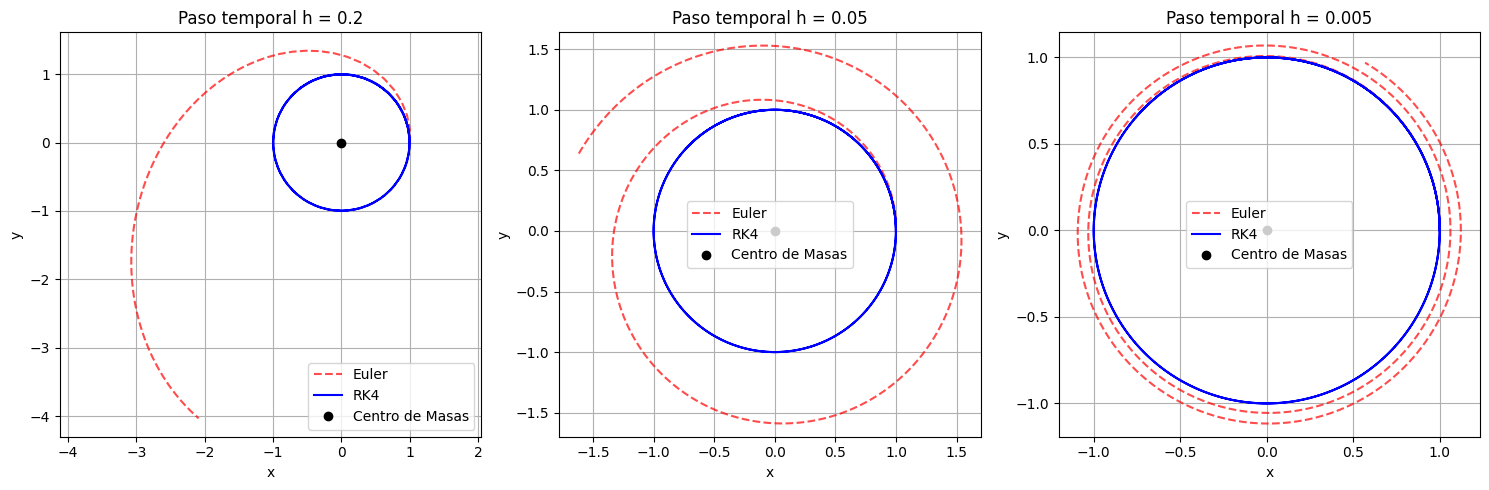

In [6]:
# 1. Condición inicial (órbita circular: x=1, y=0, vx=0, vy=1)
U0 = np.array([1.0, 0.0, 0.0, 1.0])  
t_simulacion = 15.0                  

# 2. Pasos de tiempo a evaluar (de mayor a menor)
pasos_tiempo = [0.2, 0.05, 0.005]    

# 3. Configuración del lienzo
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

for i, h in enumerate(pasos_tiempo):
    # Creamos el vector de tiempo específico para este h
    t_array = np.arange(0, t_simulacion, h)
    
    # Invocamos la función envoltorio 'integrate_cauchy' pasándole los esquemas temporales
    solucion_euler = integrate_cauchy(Euler, kepler_F, U0, t_array)
    solucion_rk4 = integrate_cauchy(RK4, kepler_F, U0, t_array)
    
    # Extraemos las coordenadas espaciales (columnas 0 y 1)
    x_euler, y_euler = solucion_euler[:, 0], solucion_euler[:, 1]
    x_rk4, y_rk4 = solucion_rk4[:, 0], solucion_rk4[:, 1]
    
    # Dibujamos las trayectorias
    axs[i].plot(x_euler, y_euler, 'r--', label='Euler', alpha=0.7)
    axs[i].plot(x_rk4, y_rk4, 'b-', label='RK4', linewidth=1.5)
    axs[i].plot(0, 0, 'ko', label='Centro de Masas')
    
    axs[i].set_title(f'Paso temporal h = {h}')
    axs[i].set_xlabel('x')
    axs[i].set_ylabel('y')
    axs[i].axis('equal')
    axs[i].grid(True)
    axs[i].legend()

plt.tight_layout()
plt.show()